# Problem 2: Implement Stochastic Gradient Descent (SGD)
---
## Q1: Batch gradient descent

Batch GD 在第 275 次迭代收敛！
Batch GD 找到的最优 theta: [  0.50325781  -2.33680098  -6.3166952    6.81229897  -1.06338282
   6.67468593   3.41178784  -0.45573762 -12.94593211  15.73289907]
最终的 Cost (误差): 8333.214221090693


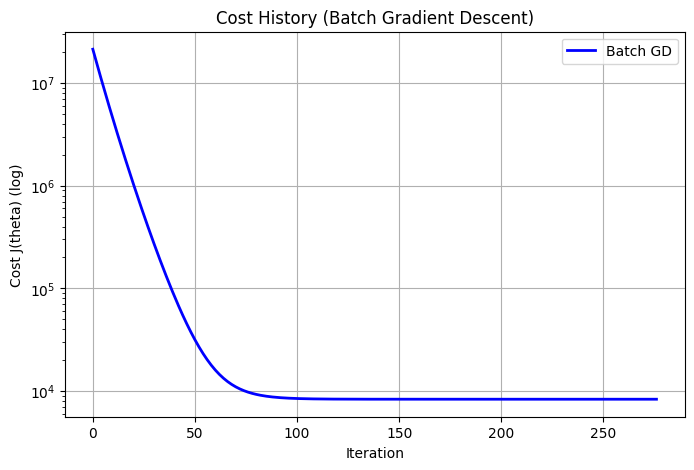

In [ ]:
# Batch gradient descent
import numpy as np
import matplotlib.pyplot as plt
import pandas

X = np.loadtxt("../p2_fittingdata_x.txt")  # it is 100*10 matrix, 100 data points, and 10 dimensions
y = np.loadtxt("../p2_fittingdatap2_y.txt")

def compute_cost(X,y,theta):
    """
    实现cost的计算
    input:
    X (Matrix) : training data
    y (scalar) : test data
    theta (matrix) : weight

    output: cost value from obj function
    """
    cost = np.sum((np.dot(X,theta)-y)**2)
    return cost

def compute_gradient(X,y,theta):
    """
    实现全批量梯度的计算
    input:
    X (Matrix) : training data
    y (scalar) : test data
    theta (matrix) : weight

    output:
    gradient: the gradient of theta
    """
    gradient = 2 * X.T.dot(X.dot(theta) - y)
    return gradient

def batch_gd(X, y, init_theta, step_size, epsilon, max_iter=2000):
    """
    执行批量梯度下降，并记录历史误差以备画图
    """
    theta = init_theta.copy()
    cost_history = []  # 用来记录每次迭代的 Loss，画图要用！

    for i in range(max_iter):
        # 记录当前的 cost
        current_cost = compute_cost(X, y, theta)
        cost_history.append(current_cost)

        # 计算全批量梯度
        grad = compute_gradient(X, y, theta)

        # 更新 theta
        next_theta = theta - step_size * grad

        # 检查收敛条件 (Loss的变化是否小于 epsilon)
        next_cost = compute_cost(X, y, next_theta)
        if abs(next_cost - current_cost) < epsilon:
            theta = next_theta
            cost_history.append(next_cost)
            print(f"Batch GD 在第 {i} 次迭代收敛！")
            break

        theta = next_theta
    return theta, cost_history


num_features = X.shape[1]
init_theta = np.zeros(num_features)

step_size_batch = 0.000001  
epsilon_batch = 1e-6
max_iter_batch = 1000

opt_theta_batch, cost_history_batch = batch_gd(X, y, init_theta, step_size_batch, epsilon_batch, max_iter_batch)

print("Batch GD 找到的最优 theta:", opt_theta_batch)
print("最终的 Cost (误差):", cost_history_batch[-1])

# 画出 Loss 随迭代次数下降的曲线
plt.figure(figsize=(8, 5))
plt.plot(cost_history_batch, color='blue', linewidth=2, label='Batch GD')

# 将 Y 轴设置为对数刻度
plt.yscale('log') 

plt.title("Cost History (Batch Gradient Descent)")
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta) (log)")
plt.grid(True)
plt.legend()
plt.show()


---
## Q2: Stochastic gradient descent

In [2]:
# Stochastic Gradient Descent (SGD)

# compute_cost Q1 已写

def compute_sgd_gradient(x_i, y_i, theta):
    """
    计算 Point-wise (单样本) 的梯度
    """
    gradient = 2 * (np.dot(x_i, theta) - y_i) * x_i
    return gradient

def dynamic_step_size(t, tau0=5000000, kappa=0.6):
    """
    计算动态衰减的学习率
    依据 Theorem 2: eta_t = (tau_0 + t)^(-kappa)
    其中 tau0 >= 0, kappa 属于 (0.5, 1)
    针对当前数据尺度，tau0 取较大值可降低初始步长，避免数值震荡
    """
    return (tau0 + t) ** (-kappa)


def sgd_function(obj, grad, data, init_guess, step_size, epsilon, max_epoch=1000):
    """
    Stochastic Gradient Descent (SGD) Function to minimize an objective function.

    Parameters:
    - obj: Objective function to minimize (evaluates over the full dataset).
    - grad: Point-wise gradient function of the objective function.
    - data: Dataset used for stochastic updates, typically a tuple (X, y).
    - init_guess: Initial guess for the parameters (a vector).
    - step_size: A function that calculates the learning rate for a given iteration t.
    - epsilon: The stopping criterion (e.g., convergence of the full objective function).
    - max_epoch: Maximum number of epochs (passes over the entire dataset) to prevent infinite loops.

    Returns:
    - opt_point: The vector of parameters that minimize the objective function.
    """
   
    X, y = data
    n_samples = X.shape[0]
    
    opt_point = init_guess.copy().astype(float)

    current_cost = obj(X, y, opt_point)
    if not np.isfinite(current_cost):
        raise ValueError("初始 cost 非有限值，请检查数据或参数设置。")
    
    t = 1 # 全局迭代计数器，用于计算动态步长
    
    for epoch in range(max_epoch):
        # 1. Shuffle data，保证每次遍历的样本顺序都是随机的
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # 2. 遍历每一个数据样本
        for i in range(n_samples):
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            current_grad = grad(x_i, y_i, opt_point)    # 计算点级梯度
            lr = step_size(t)   # 获取当前的动态步长
            opt_point = opt_point - lr * current_grad   # 更新参数

            t += 1  # 更新参数
            
        # 3. 每个 Epoch 结束后，在“整个数据集”上评估一次误差，以判断是否收敛
        next_cost = obj(X, y, opt_point)
        
        if abs(next_cost - current_cost) < epsilon:
            print(f"SGD 收敛于第 {epoch + 1} 个 Epoch (全局迭代了 {t-1} 次单样本更新)")
            break
            
        current_cost = next_cost

    return opt_point

num_features = X.shape[1]
init_theta = np.zeros(num_features)

data_tuple = (X, y)
epsilon_sgd = 1e-6
max_epoch_sgd = 1000

np.random.seed(42)  # 随机种子，保证可复现
opt_theta_sgd_q2 = sgd_function(
    obj=compute_cost,
    grad=compute_sgd_gradient,
    data=data_tuple,
    init_guess=init_theta,
    step_size=dynamic_step_size,
    epsilon=epsilon_sgd,
    max_epoch=max_epoch_sgd
)

final_cost_sgd_q2 = compute_cost(X, y, opt_theta_sgd_q2)
print("SGD 找到的最优 theta:", opt_theta_sgd_q2)
print("SGD 最终的 Cost (误差):", final_cost_sgd_q2)



SGD 找到的最优 theta: [  0.54818127  -2.34508764  -6.35249989   6.89447392  -1.07338146
   6.6974685    3.41346457  -0.54220124 -13.10875814  15.68105391]
SGD 最终的 Cost (误差): 10627.357533965898


---
## Q3: Comparison between batch and stochastic GD


SGD 找到的最优 theta: [  0.54818127  -2.34508764  -6.35249989   6.89447392  -1.07338146
   6.6974685    3.41346457  -0.54220124 -13.10875814  15.68105391]
SGD 最终的 Cost (误差): 10627.357533965898


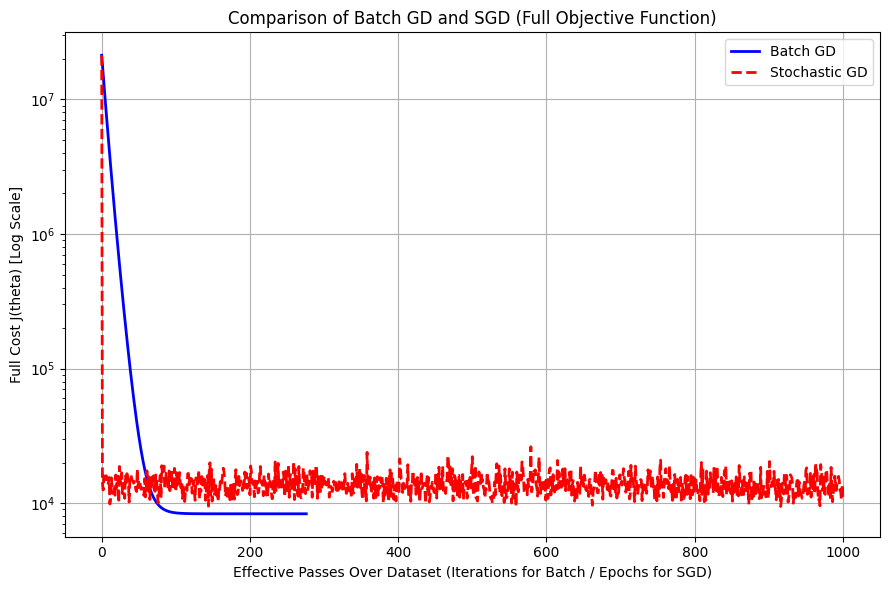

In [3]:
# 重新定义 sgd_function函数, 新增 return cost_history列表，便于后续绘图

def sgd_function(obj, grad, data, init_guess, step_size, epsilon, max_epoch=100):
    """
    Stochastic Gradient Descent (SGD) Function to minimize an objective function.

    Parameters:
    - obj: Objective function to minimize (evaluates over the full dataset).
    - grad: Point-wise gradient function of the objective function.
    - data: Dataset used for stochastic updates, typically a tuple (X, y).
    - init_guess: Initial guess for the parameters (a vector).
    - step_size: A function that calculates the learning rate for a given iteration t.
    - epsilon: The stopping criterion (e.g., convergence of the full objective function).
    - max_epoch: Maximum number of epochs (passes over the entire dataset) to prevent infinite loops.

    Returns:
    - opt_point: The vector of parameters that minimize the objective function.
    """
   
    X, y = data
    n_samples = X.shape[0]
    
    opt_point = init_guess.copy().astype(float)

    current_cost = obj(X, y, opt_point)
    if not np.isfinite(current_cost):
        raise ValueError("初始 cost 非有限值，请检查数据或参数设置。")
    # 创建一个列表，把初始误差装进去
    cost_history = [current_cost] 
    
    t = 1 # 全局迭代计数器，用于计算动态步长
    
    for epoch in range(max_epoch):
        # 1. Shuffle data，保证每次遍历的样本顺序都是随机的
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # 2. 遍历每一个数据样本
        for i in range(n_samples):
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            # 计算点级梯度
            current_grad = grad(x_i, y_i, opt_point)
            # 获取当前的动态步长
            lr = step_size(t)
            # 更新参数
            opt_point = opt_point - lr * current_grad

            # 全局计数加一
            t += 1
            
        # 3. 每个 Epoch 结束后，在“整个数据集”上评估一次误差，以判断是否收敛
        next_cost = obj(X, y, opt_point)
        # 把这个 Epoch 结束后的误差存进历史记录里
        cost_history.append(next_cost)
        
        if abs(next_cost - current_cost) < epsilon:
            print(f"SGD 收敛于第 {epoch + 1} 个 Epoch (全局迭代了 {t-1} 次单样本更新)")
            break
            
        current_cost = next_cost

    return opt_point, cost_history


# 准备超参数
data_tuple = (X, y)
epsilon_sgd = 1e-6
max_epoch_sgd = 1000


np.random.seed(42)  # 随机种子，保证可复现
# 运行 SGD 
opt_theta_sgd, cost_history_sgd = sgd_function(
    obj=compute_cost, 
    grad=compute_sgd_gradient, 
    data=data_tuple, 
    init_guess=init_theta, 
    step_size=dynamic_step_size, 
    epsilon=epsilon_sgd, 
    max_epoch=max_epoch_sgd
)

print("\nSGD 找到的最优 theta:", opt_theta_sgd)
print("SGD 最终的 Cost (误差):", cost_history_sgd[-1])

# ----------------- 画 Q3 对比图 -----------------
plt.figure(figsize=(9, 6))

# 画出 Batch GD 的下降曲线 (蓝色)
plt.plot(cost_history_batch, color='blue', linewidth=2, label='Batch GD')

# 只使用有限且正的值用于 log 绘图，避免 overflow
cost_history_sgd_safe = np.asarray(cost_history_sgd, dtype=float)
valid_mask = np.isfinite(cost_history_sgd_safe) & (cost_history_sgd_safe > 0)
if np.any(valid_mask):
    valid_idx = np.where(valid_mask)[0]
    plt.plot(valid_idx, cost_history_sgd_safe[valid_mask], color='red', linewidth=2, linestyle='--', label='Stochastic GD')
else:
    print("警告：SGD cost 全部为非有限值或非正值，跳过曲线绘制。")

# 设置对数坐标轴
plt.yscale('log') 

# 设置图表标签
plt.title("Comparison of Batch GD and SGD (Full Objective Function)")
plt.xlabel("Effective Passes Over Dataset (Iterations for Batch / Epochs for SGD)")
plt.ylabel("Full Cost J(theta) [Log Scale]")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

---
## Q4: Mini-batch Gradient Descent

Mini-batch GD 找到的最优 theta: [  0.52851005  -2.3482505   -6.25195775   6.80056544  -1.1189036
   6.6948542    3.38747759  -0.48983789 -12.95453521  15.70830578]
Mini-batch GD 最终 Cost: 8725.947850596984


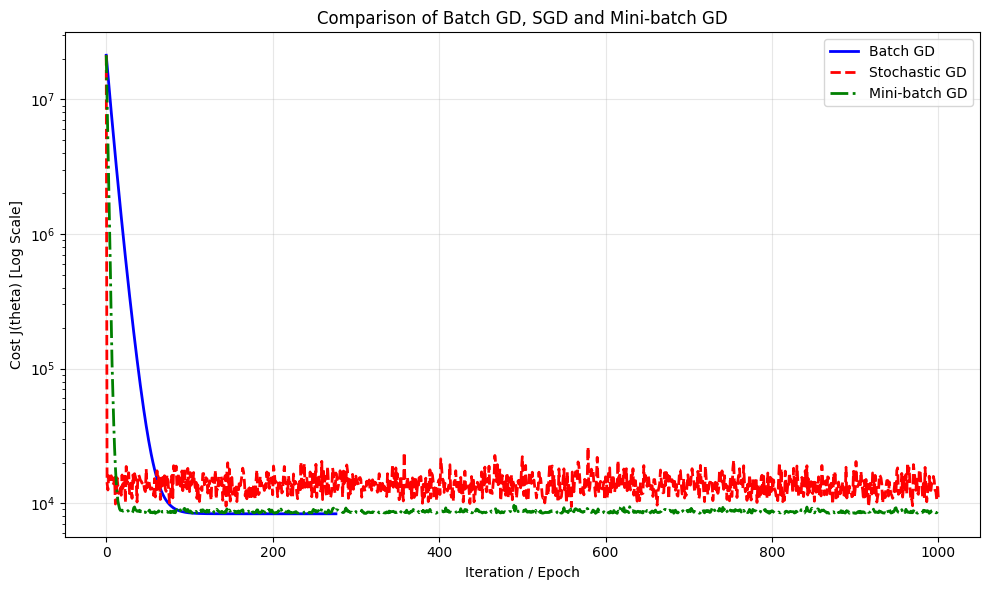

In [12]:
# Mini-batch Gradient Descent

def dynamic_step_size_minibatch(t, tau0=3000000, kappa=0.6):
    """
    Mini-batch 专用动态学习率。
    与 SGD 的 dynamic_step_size 区分开，避免步长设置不匹配。
    """
    return (tau0 + t) ** (-kappa)


def minibatch_gd_function(obj, grad, data, init_guess, step_size, epsilon, n_batch=32, max_epoch=1000):
    """
    Mini-batch Gradient Descent Function to minimize an objective function.

    Parameters:
    - obj: Objective function to minimize (evaluates over the full dataset).
    - grad: Gradient function of the objective function (evaluates over a mini-batch).
    - data: Dataset used for stochastic updates, typically a tuple (X, y).
    - init_guess: Initial guess for the parameters (a vector).
    - step_size: A function that calculates the learning rate for a given iteration t.
    - epsilon: The stopping criterion (e.g., convergence of the full objective function).
    - n_batch: The size of each mini-batch.
    - max_epoch: Maximum number of epochs (passes over the entire dataset) to prevent infinite loops.

    Returns:
    - opt_point: The vector of parameters that minimize the objective function.
    - cost_history: Cost history over epochs.
    """

    X, y = data
    n_samples = X.shape[0]

    if n_batch <= 0:
        raise ValueError("n_batch 必须是正整数。")

    # 若 batch size 大于样本总数，退化为 full-batch
    n_batch = min(n_batch, n_samples)

    opt_point = init_guess.copy().astype(float)

    current_cost = obj(X, y, opt_point)
    if not np.isfinite(current_cost):
        raise ValueError("初始 cost 非有限值，请检查数据或参数设置。")

    cost_history = [current_cost]
    t = 1  # 全局迭代计数器，用于计算动态步长

    for epoch in range(max_epoch):
        # Shuffle data，保证每次 Epoch 的 batch 采样是随机的
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # 按 mini-batch 更新参数
        for start in range(0, n_samples, n_batch):
            end = start + n_batch
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            current_grad = grad(X_batch, y_batch, opt_point)
            current_grad = current_grad / X_batch.shape[0] # 平均梯度

            lr = step_size(t)
            opt_point = opt_point - lr * current_grad
            t += 1

        # 每个 Epoch 结束后，在整个数据集上评估一次误差，判断是否收敛
        next_cost = obj(X, y, opt_point)
        cost_history.append(next_cost)

        if not np.isfinite(next_cost):
            print(f"Mini-batch GD 在第 {epoch + 1} 个 Epoch 出现非有限值，提前停止。")
            break

        if abs(next_cost - current_cost) < epsilon:
            print(f"Mini-batch GD 收敛于第 {epoch + 1} 个 Epoch (全局迭代了 {t-1} 次 batch 更新)")
            break

        current_cost = next_cost

    return opt_point, cost_history


np.random.seed(42)
opt_theta_minibatch, cost_history_minibatch = minibatch_gd_function(
    obj=compute_cost,
    grad=compute_gradient,
    data=(X, y),
    init_guess=init_theta,
    step_size=dynamic_step_size_minibatch,
    epsilon=1e-6,
    n_batch=32,
    max_epoch=1000
)

print("Mini-batch GD 找到的最优 theta:", opt_theta_minibatch)
print("Mini-batch GD 最终 Cost:", compute_cost(X, y, opt_theta_minibatch))


#——————————————————————Batch GD vs SGD vs Mini-batch GD (三条曲线对比)————————————————————————————
required_vars = ["cost_history_batch", "cost_history_sgd", "cost_history_minibatch"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"请先运行 Q1/Q3/Q4 单元，缺少变量: {missing}")

plt.figure(figsize=(10, 6))

# Batch GD
batch_vals = np.asarray(cost_history_batch, dtype=float)
batch_mask = np.isfinite(batch_vals) & (batch_vals > 0)
if np.any(batch_mask):
    batch_idx = np.where(batch_mask)[0]
    plt.plot(batch_idx, batch_vals[batch_mask], color="blue", linewidth=2, label="Batch GD")

# SGD
sgd_vals = np.asarray(cost_history_sgd, dtype=float)
sgd_mask = np.isfinite(sgd_vals) & (sgd_vals > 0)
if np.any(sgd_mask):
    sgd_idx = np.where(sgd_mask)[0]
    plt.plot(sgd_idx, sgd_vals[sgd_mask], color="red", linewidth=2, linestyle="--", label="Stochastic GD")

# Mini-batch GD
mb_vals = np.asarray(cost_history_minibatch, dtype=float)
mb_mask = np.isfinite(mb_vals) & (mb_vals > 0)
if np.any(mb_mask):
    mb_idx = np.where(mb_mask)[0]
    plt.plot(mb_idx, mb_vals[mb_mask], color="green", linewidth=2, linestyle="-.", label="Mini-batch GD")

plt.yscale("log")
plt.title("Comparison of Batch GD, SGD and Mini-batch GD")
plt.xlabel("Iteration / Epoch")
plt.ylabel("Cost J(theta) [Log Scale]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 附：不同超参数下的sgd曲线对比图

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) 前置检查：确保之前的变量已存在 ----------
required_vars = ["X", "y", "init_theta", "compute_cost", "compute_sgd_gradient", "cost_history_batch"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"请先运行前面的 Q1/Q2 单元格，缺少必要的变量: {missing}")

# ---------- 2) 带有历史记录的 SGD 函数 ----------
def sgd_function_with_history(obj, grad, data, init_guess, step_size_fn, epsilon, max_epoch=1000, grad_clip=1e4):
    X_local, y_local = data
    n_samples = X_local.shape[0]
    
    theta = init_guess.copy().astype(float)
    current_cost = obj(X_local, y_local, theta)
    
    cost_history = [current_cost]
    t = 1 
    
    for epoch in range(max_epoch):
        # 打乱数据集
        indices = np.random.permutation(n_samples)
        X_shuffled = X_local[indices]
        y_shuffled = y_local[indices]
        
        for i in range(n_samples):
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            
            # 计算梯度并截断（防止严重发散报错）
            current_grad = grad(x_i, y_i, theta)
            if grad_clip is not None:
                current_grad = np.clip(current_grad, -grad_clip, grad_clip)
                
            lr = step_size_fn(t)
            theta = theta - lr * current_grad
            t += 1
            
        # 每个 epoch 后计算全量误差
        next_cost = obj(X_local, y_local, theta)
        cost_history.append(next_cost)
        
        # 提前停止条件
        if abs(next_cost - current_cost) < epsilon:
            break
        current_cost = next_cost

    return theta, cost_history

# ---------- 3) 设定超参数组合 ----------
# tau0: 极大, 大, 合适, 小
tau_levels = [
    (50000000, "tau0=5e7 (Very Large)"),
    (5000000,  "tau0=5e6 (Large)"),
    (500000,   "tau0=5e5 (Suitable)"),
    (50000,    "tau0=5e4 (Small)")
]
# kappa: Theorem 2 要求在 (0.5, 1) 之间
kappa_levels = [0.6, 0.7, 0.8]

# ---------- 4) 批量运行并绘制 4x3 网格图 ----------
np.random.seed(42)  # 固定随机性，保证可复现
data_tuple = (X, y)
epsilon_sgd_cmp = 1e-6
max_epoch_sgd_cmp = 1000

# 创建 4x3 的画布
fig, axes = plt.subplots(nrows=len(tau_levels), ncols=len(kappa_levels), 
                         figsize=(18, 16), sharex=True, sharey=True)

# 避免对数图因为极大/极小值崩溃的安全界限
Y_MIN_SAFE = 1e-1
Y_MAX_SAFE = 1e8

print("开始运行批量 SGD 测试...\n")

for row, (tau0, tau_label) in enumerate(tau_levels):
    for col, kappa in enumerate(kappa_levels):
        ax = axes[row, col]
        
        # 定义当前 case 的步长函数
        def step_size_case(t, t0=tau0, k=kappa):
            return (t0 + t) ** (-k)
        
        # 运行 SGD
        theta_case, cost_hist_case = sgd_function_with_history(
            obj=compute_cost,
            grad=compute_sgd_gradient,
            data=data_tuple,
            init_guess=init_theta,
            step_size_fn=step_size_case,
            epsilon=epsilon_sgd_cmp,
            max_epoch=max_epoch_sgd_cmp
        )
        
        # 提取 Batch GD 和 SGD 数据
        bgd = np.asarray(cost_history_batch, dtype=float)
        sgd = np.asarray(cost_hist_case, dtype=float)

        bgd_mask = np.isfinite(bgd) & (bgd > 0)
        sgd_mask = np.isfinite(sgd) & (sgd > 0)

        # 绘制 Batch GD (蓝色实线)
        if np.any(bgd_mask):
            bgd_idx = np.where(bgd_mask)[0]
            bgd_vals = np.clip(bgd[bgd_mask], Y_MIN_SAFE, Y_MAX_SAFE)
            ax.plot(bgd_idx, bgd_vals, color="blue", linewidth=2.5, alpha=0.7, label="Batch GD")

        # 绘制 SGD (红色虚线)
        if np.any(sgd_mask):
            sgd_idx = np.where(sgd_mask)[0]
            sgd_vals = np.clip(sgd[sgd_mask], Y_MIN_SAFE, Y_MAX_SAFE)
            ax.plot(sgd_idx, sgd_vals, color="red", linewidth=1.5, linestyle="--", label="SGD")

        # 设置图表格式
        ax.set_yscale("log")
        ax.set_ylim(Y_MIN_SAFE, Y_MAX_SAFE)
        ax.set_title(f"{tau_label}\nkappa = {kappa}", fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        if row == len(tau_levels) - 1:
            ax.set_xlabel("Epoch / Iteration", fontsize=10)
        if col == 0:
            ax.set_ylabel("Cost (log scale)", fontsize=10)
        if row == 0 and col == 0:
            ax.legend(loc="upper right")
            
        final_cost = compute_cost(X, y, theta_case)
        print(f"完成: {tau_label}, kappa={kappa} | 最终 Cost: {final_cost:.4f}")

fig.suptitle("Hyperparameter Analysis for SGD vs Batch GD", fontsize=16, y=0.98)
plt.tight_layout()
fig.subplots_adjust(top=0.92)

# 自动保存为高清图片
save_path = "sgd_hyperparameter_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n图片已成功保存至当前目录: {save_path}")

plt.show()